<a href="https://colab.research.google.com/github/GroupQ-Assignment-DataScience/GroupQ_Assignment_RMD/blob/main/GroupQ.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import numpy as np
from matplotlib import pyplot as plt
from sklearn import preprocessing

In [9]:
import pandas as pd
df = pd.read_csv('/content/dataset_C_training.csv')

In [10]:
df.head()

,respondent_id,covid_concern,covid_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,employment_status,census_msa,household_adults,household_children,doctor_recc_covid,opinion_covid_vacc_effective,opinion_covid_risk,opinion_covid_sick_from_vacc,employment_sector,covid_vaccine
0,1,3.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Employed,"MSA, Principle City",3.0,2.0,0,4,4,2.0,construction,0
1,2,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Employed,Non-MSA,0.0,0.0,0,5,2,1.0,education,1
2,3,0.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,2,2,5.0,wholesale,0
3,4,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,...,Not in Labor Force,"MSA, Not Principle City",1.0,0.0,1,3,3,2.0,NaN,1
4,5,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Employed,"MSA, Not Principle City",0.0,0.0,0,3,2,2.0,wholesale,0


In [12]:
# Install H20AutoML (only need to do this once)
!pip install h2o

# Import packages
import h2o
from h2o.automl import H2OAutoML

# Start the H2O cluster (locally)
h2o.init()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 266.4/266.4 MB 5.7 MB/s eta 0:00:00
Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.18" 2026-01-20; OpenJDK Runtime Environment (build 17.0.18+8-Ubuntu-122.04.1); OpenJDK 64-Bit Server VM (build 17.0.18+8-Ubuntu-122.04.1, mixed mode, sharing)
  Starting server from /usr/local/lib/python3.12/dist-packages/h2o/backend/bin/h2o.jar
  Ice root: /tmp/tmpl7hfobfa
  JVM stdout: /tmp/tmpl7hfobfa/h2o_unknownUser_started_from_python.out
  JVM stderr: /tmp/tmpl7hfobfa/h2o_unknownUser_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.


H2O_cluster_uptime:,03 secs
H2O_cluster_timezone:,Etc/UTC
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.11
H2O_cluster_version_age:,14 days and 36 minutes
H2O_cluster_name:,H2O_from_python_unknownUser_o1ccaf
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,3.168 Gb
H2O_cluster_total_cores:,2
H2O_cluster_allowed_cores:,2
H2O_cluster_status:,"locked, healthy"


In [15]:
# Define the target variable (i.e. "response") and features (i.e. "predictors") for H20AutoML
response = 'covid_vaccine'
predictors = list(df.drop('covid_vaccine', axis=1).columns)

# Convert from a pandas dataframe to an h20 frame
hf = h2o.H2OFrame(df)

# Convert target column to categorical, as this is a binary classification problem
hf['covid_vaccine'] = hf['covid_vaccine'].asfactor()

# Split the data into training and testing sets using the H20 split_frame() method
train, test = hf.split_frame(seed=1, ratios=[0.75])

Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%


In [16]:
# Set-up and train the models
aml = H2OAutoML(max_runtime_secs=120, seed=1, include_algos=["GLM", "DRF", "XGBoost"])
aml.train(x=predictors, y=response, training_frame=train)

# Turn off default printed output
h2o.display.toggle_user_tips()

AutoML progress: |███████████████████████████████████████████████████████████████| (done) 100%


In [17]:
# Show leaderboard & performance information
aml.explain(test, include_explanations=["leaderboard"]);

# Leaderboard

> Leaderboard shows models with their metrics. When provided with H2OAutoML object, the leaderboard shows 5-fold cross-validated metrics by default (depending on the H2OAutoML settings), otherwise it shows metrics computed on the frame. At most 20 models are shown by default.

model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse,training_time_ms,predict_time_per_row_ms,algo
XGBoost_3_AutoML_1_20260605_103146,0.852352,0.450119,0.752071,0.220807,0.378058,0.142928,1232,0.013179,XGBoost
XGBoost_grid_1_AutoML_1_20260605_103146_model_2,0.851511,0.450196,0.757612,0.220852,0.37799,0.142876,1794,0.015219,XGBoost
XGBoost_grid_1_AutoML_1_20260605_103146_model_5,0.848938,0.447788,0.753918,0.221446,0.377551,0.142545,639,0.009758,XGBoost
XGBoost_grid_1_AutoML_1_20260605_103146_model_1,0.848723,0.457662,0.74374,0.224139,0.380552,0.14482,1566,0.013531,XGBoost
DRF_1_AutoML_1_20260605_103146,0.848043,0.446797,0.758916,0.220325,0.378821,0.143505,3854,0.065685,DRF
XGBoost_1_AutoML_1_20260605_103146,0.847736,0.45869,0.742466,0.223599,0.380703,0.144934,2039,0.014019,XGBoost
XGBoost_grid_1_AutoML_1_20260605_103146_model_3,0.846155,0.457092,0.754666,0.216421,0.378658,0.143382,2316,0.016373,XGBoost
XGBoost_grid_1_AutoML_1_20260605_103146_model_4,0.84541,0.462589,0.751633,0.216443,0.381195,0.14531,1048,0.014622,XGBoost
XGBoost_2_AutoML_1_20260605_103146,0.838902,0.474292,0.739744,0.231284,0.386726,0.149557,1264,0.023629,XGBoost
XRT_1_AutoML_1_20260605_103146,0.836592,0.472718,0.738579,0.237453,0.390744,0.152681,1408,0.06667,DRF


# Variable Importance Heatmap

> Variable importance heatmap shows variable importance across multiple models. Some models in H2O return variable importance for one-hot (binary indicator) encoded versions of categorical columns (e.g. Deep Learning, XGBoost). In order for the variable importance of categorical columns to be compared across all model types we compute a summarization of the the variable importance across all one-hot encoded features and return a single variable importance for the original categorical feature. By default, the models and variables are ordered by their similarity.

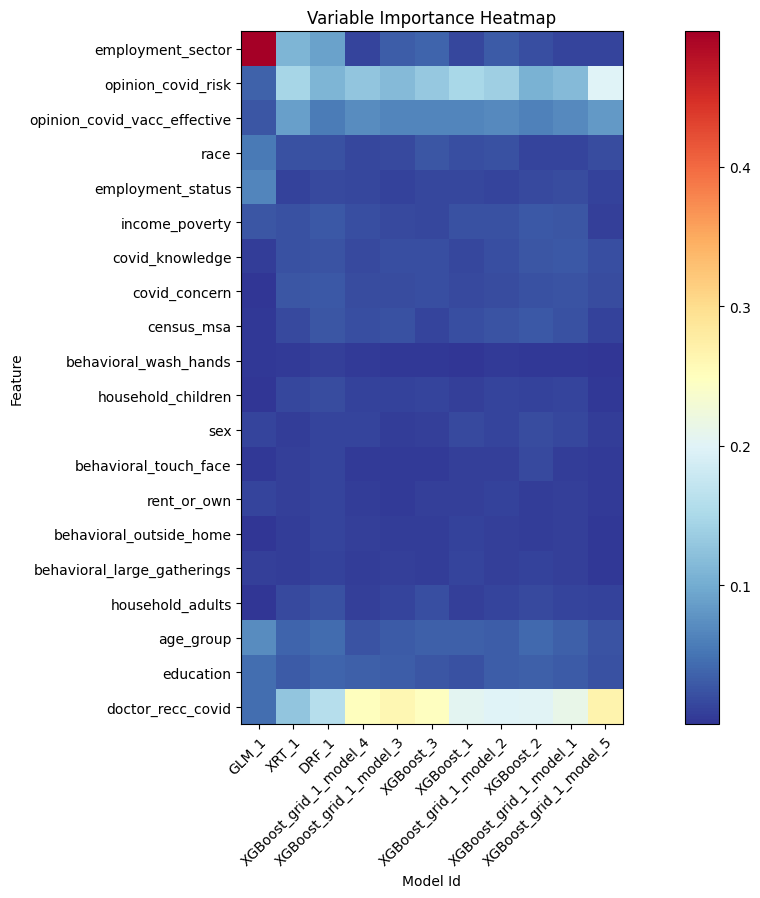

# Partial Dependence Plots

> Partial dependence plot (PDP) gives a graphical depiction of the marginal effect of a variable on the response. The effect of a variable is measured in change in the mean response. PDP assumes independence between the feature for which is the PDP computed and the rest.

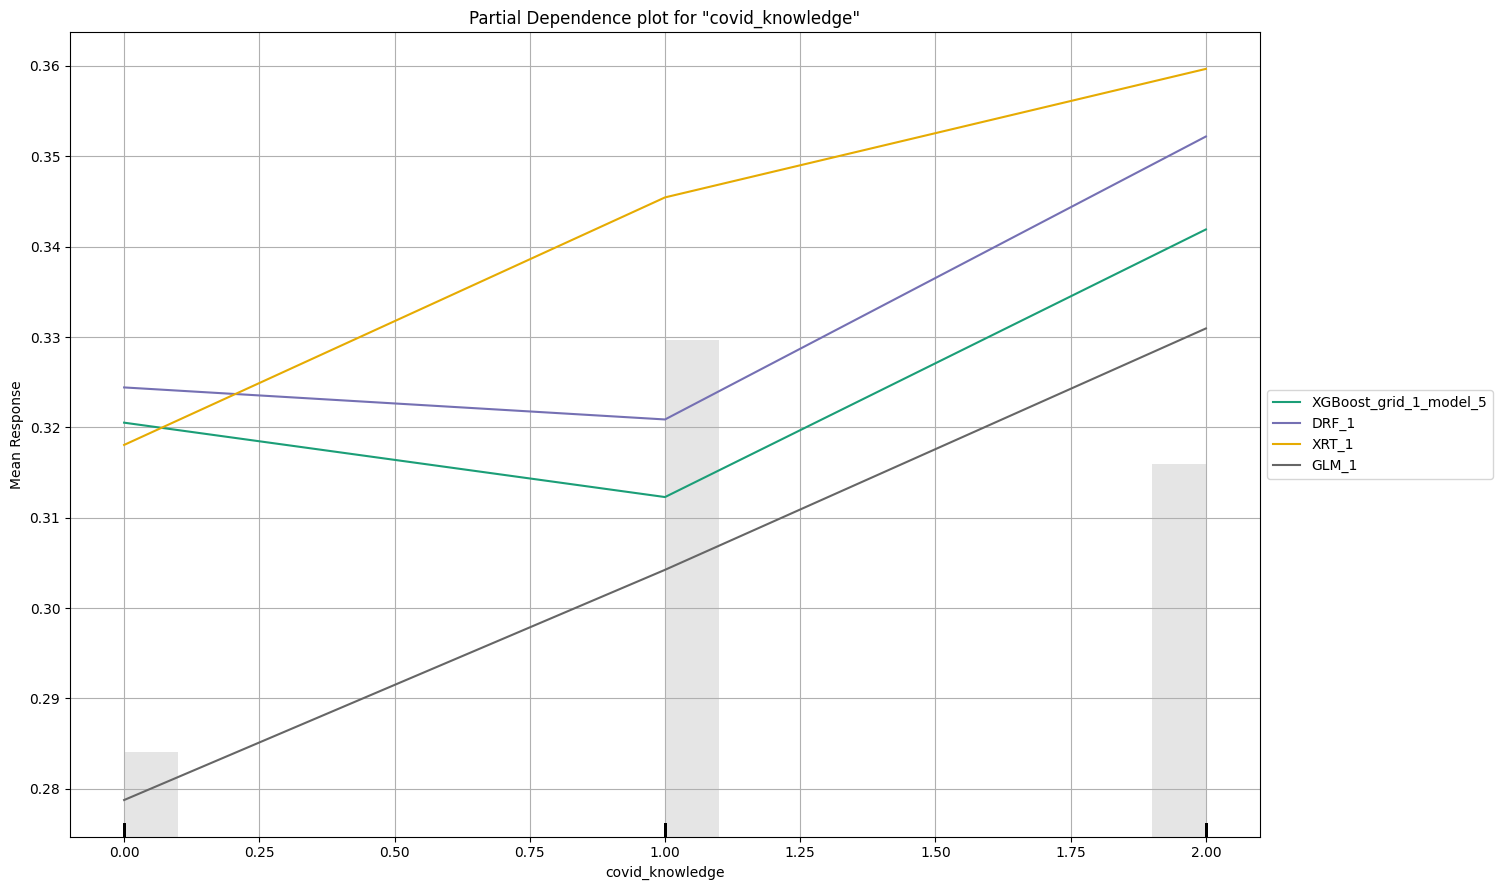

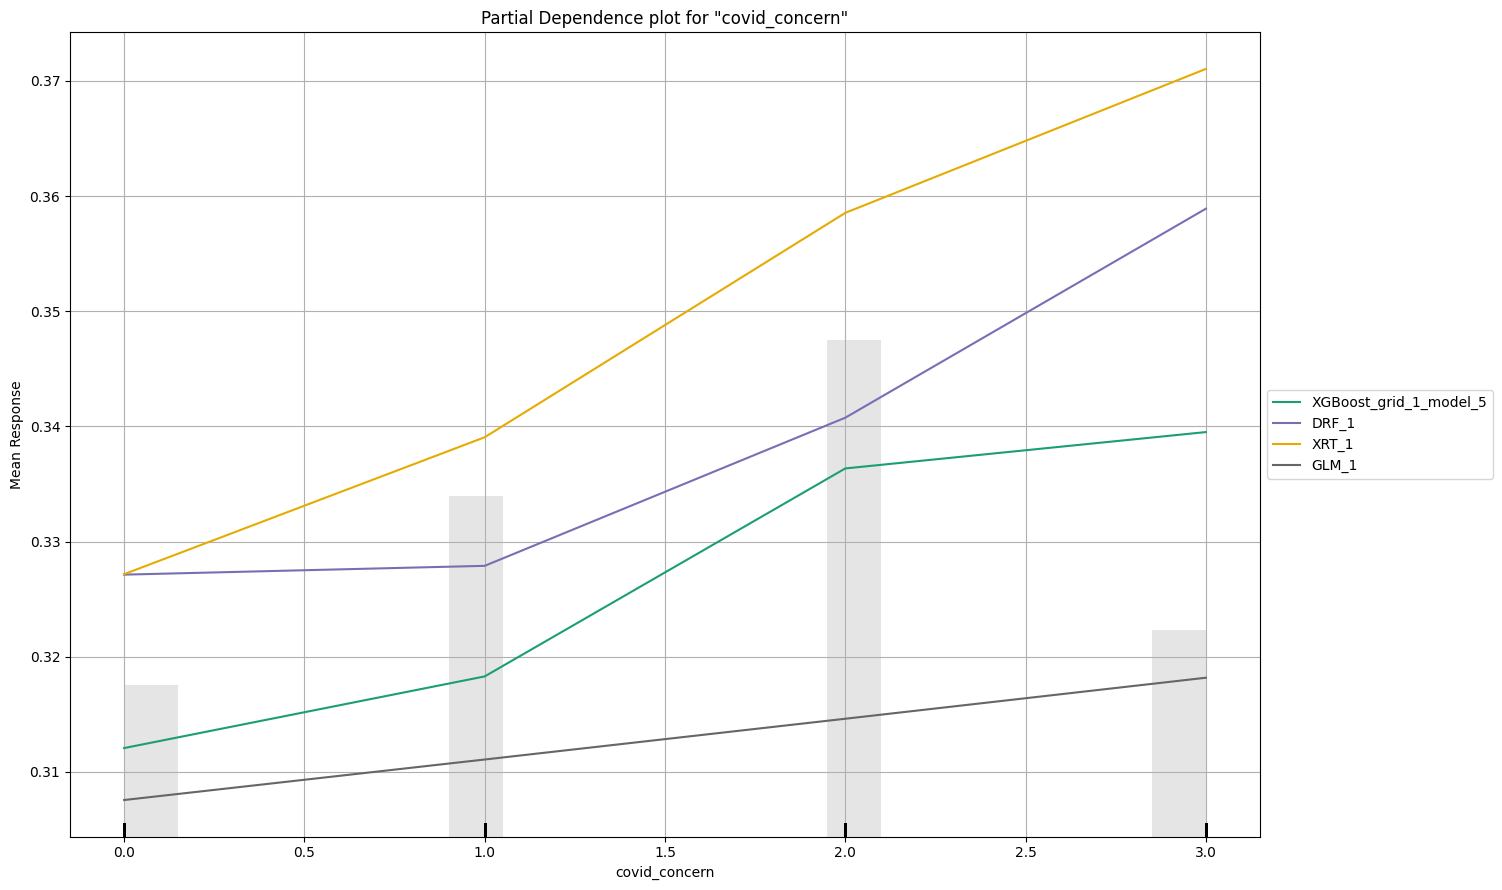

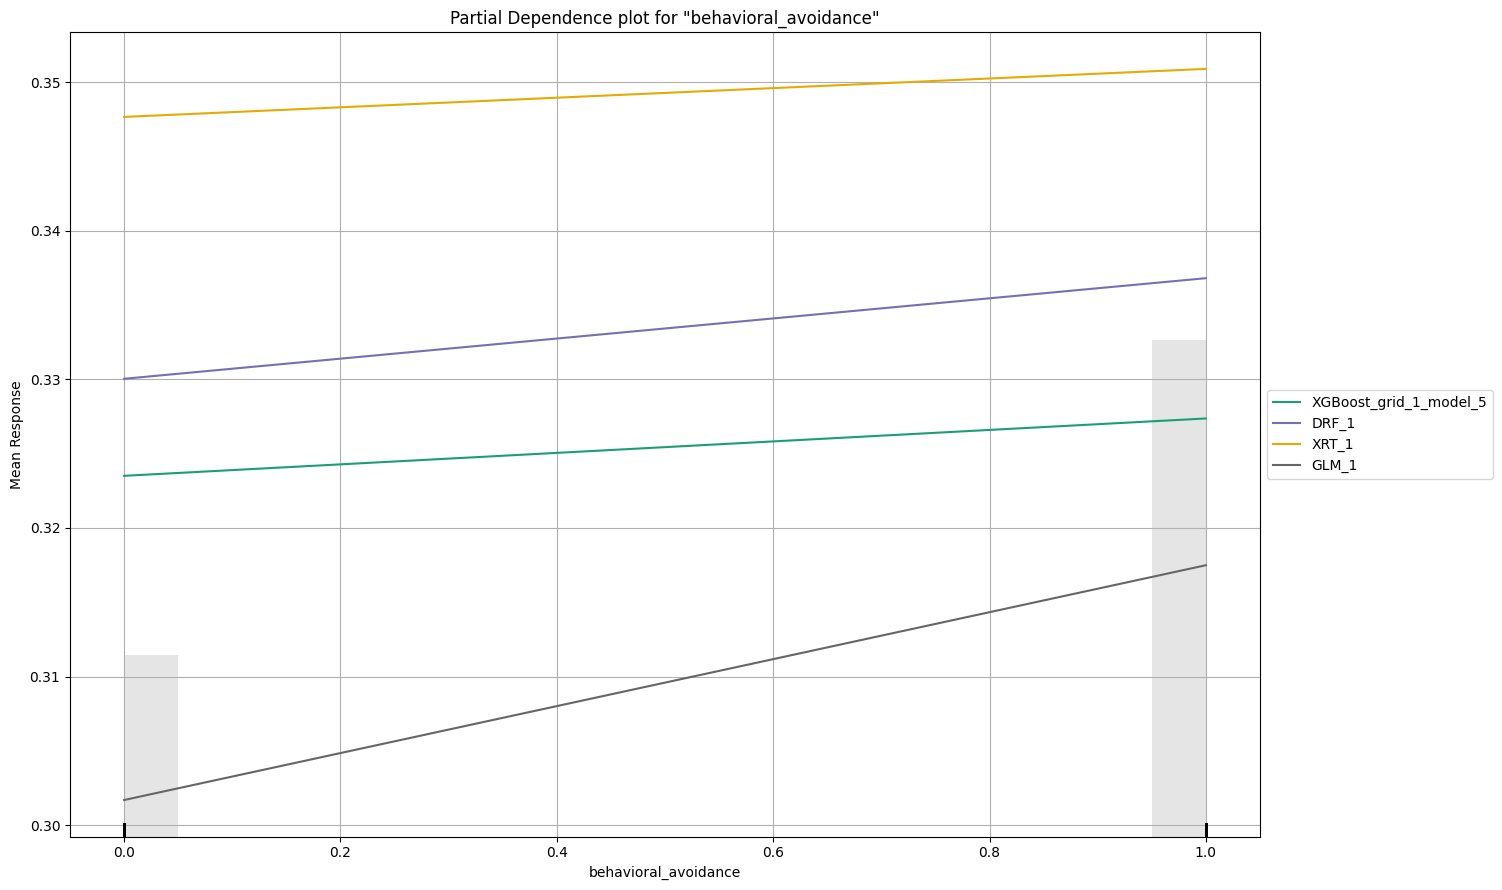

In [20]:
# Plot XAI information
aml.explain(test, include_explanations=["varimp_heatmap", "pdp"], \
            columns = ["covid_knowledge", "covid_concern", "behavioral_avoidance"]);

In [43]:
best_model = aml.leader
predictions = best_model.predict(test)

# Display predictions (first 5 rows)
print("Predictions:")
predictions.head()

glm prediction progress: |███████████████████████████████████████████████████████| (done) 100%
Predictions:


predict,p0,p1
0,0.919646,0.0803542
0,0.762165,0.237835
0,0.907616,0.0923841
0,0.857999,0.142001
0,0.926802,0.073198
0,0.861965,0.138035
1,0.397016,0.602984
0,0.657949,0.342051
0,0.93457,0.0654299
0,0.85589,0.14411


In [44]:
print("Model performance on test set:")
performance = best_model.model_performance(test)
print(performance)

Model performance on test set:
ModelMetricsBinomialGLM: glm
** Reported on test data. **

MSE: 0.15439614730837398
RMSE: 0.3929327516361724
LogLoss: 0.48210312960859975
AUC: 0.8199163978460076
AUCPR: 0.7301818271007682
Gini: 0.6398327956920151
Null degrees of freedom: 1179
Residual degrees of freedom: 1149
Null deviance: 1509.6126773117362
Residual deviance: 1137.7633858762956
AIC: 1199.7633858762956

Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)

Maximum Metrics: Maximum metrics at their respective thresholds
metric                       threshold    value     idx
---------------------------  -----------  --------  -----
max f1                       0.265719     0.677668  236
max f2                       0.200891     0.757238  274
max f0point5                 0.436315   

In [45]:
print(f"AUC: {performance.auc()}")
print(f"F1 Score: {performance.F1()}")
print("Confusion Matrix:")
print(performance.confusion_matrix())

AUC: 0.8199163978460076
F1 Score: [[0.2657194530003334, 0.6776677667766776]]
Confusion Matrix:
Confusion Matrix (Act/Pred) for max f1 @ threshold = 0.2657194530003334
       0    1    Error    Rate
-----  ---  ---  -------  --------------
0      579  203  0.2596   (203.0/782.0)
1      90   308  0.2261   (90.0/398.0)
Total  669  511  0.2483   (293.0/1180.0)


In [46]:
leaderboard_df = aml.leaderboard.as_data_frame()
display(leaderboard_df.head(5))

/usr/local/lib/python3.12/dist-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,auc,logloss,aucpr,mean_per_class_error,rmse,mse
0,GLM_1_AutoML_2_20260605_105925,0.828588,0.466215,0.712891,0.236188,0.385363,0.148504
1,XGBoost_grid_1_AutoML_2_20260605_105925_model_2,0.818713,0.480151,0.694480,0.245530,0.392072,0.153720
2,XGBoost_grid_1_AutoML_2_20260605_105925_model_6,0.817526,0.481823,0.698494,0.252263,0.393183,0.154593
3,XGBoost_3_AutoML_2_20260605_105925,0.817424,0.480952,0.700840,0.252904,0.392900,0.154370
4,DRF_1_AutoML_2_20260605_105925,0.813676,0.482737,0.699887,0.248752,0.393703,0.155002
